### 1. Importação e Setup

Importação de bibliotecas base, módulos personalizados do projeto (data, utils, models) e criação dos diretórios de resultados e dados.

In [19]:
import numpy as np
import pandas as pd
import importlib
import shap
import joblib
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

import src.data.pipeline as data_transform
import src.utils.analyze as data_analyze
import src.models.train as train_models
import src.config as cfg

importlib.reload(cfg)
importlib.reload(data_transform)
importlib.reload(data_analyze)
importlib.reload(train_models)

cfg.RESULTS_PATH.mkdir(parents=True, exist_ok=True)
cfg.DATA_PATH.mkdir(parents=True, exist_ok=True)

### 2. Processamento e Análise de Dados

Executa a pipeline de transformação dos dados brutos (ou carrega o ficheiro já processado) e realiza a análise exploratória.

In [20]:
if cfg.RUN_TRANSFORMATION:
    print("A iniciar transformação dos dados brutos...")
    raw_df = pd.read_csv(cfg.RAW_DATA_PATH, sep=',')
    
    # Aplicar transformações
    df = data_transform.transform_data(raw_df)
    
    # Garantir que a pasta 'data' existe e guardar o csv
    df.to_csv(cfg.PROCESSED_FILE_PATH, index=False)
    print(f"Dados transformados e guardados em: {cfg.PROCESSED_FILE_PATH}\n")

else:
    print("A carregar dados já processados da pasta data...")
    df = pd.read_csv(cfg.PROCESSED_FILE_PATH)
    
    # Reconverter as colunas de data (o CSV guarda como string)
    df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
    df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Correr a análise aos dados finais carregados em memória
data_analyze.analyze_data(df)

A iniciar transformação dos dados brutos...
[*] Registos removidos (Tempo de espera negativo): 5
Dados transformados e guardados em: c:\Users\thale\Desktop\UC\master-projects\advanced-infrastructures-for-datascience\data\processed_appointments.csv


--- Balanceamento da Classe Alvo (No-show) ---
         Contagem  Percentagem (%)
No-show                           
False       88208            79.81
True        22314            20.19
--- Contagem de Valores Nulos ---
PatientId               0
Gender                  0
ScheduledDay            0
AppointmentDay          0
Age                     0
Neighbourhood           0
SMS_received            0
No-show                 0
WaitingDays             0
ScheduledHour           0
ScheduledDayOfWeek      0
AppointmentDayOfWeek    0
AppointmentMonth        0
dtype: int64

--- Distribuição das Variáveis Categóricas (%) ---

Gender:
Gender
F    65.0
M    35.0
Name: proportion, dtype: float64

SMS_received:
SMS_received
0    67.9
1    32.1
Name: pro

### 3. Pré-processamento e Divisão dos Dados
Processamento das características, divisão dos dados em conjuntos de treino e teste, e inspeção estrutural do conjunto de dados pronto para modelação.

In [21]:
print("A processar features...")
X, y = train_models.preprocess_features(df)

# Split inicial para a fase de otimização
X_train_opt, X_test_opt, y_train_opt, y_test_opt = train_test_split(X, y, test_size=cfg.TEST_SIZE, random_state=42)

# Analisar a estrutura de X e y após o pré-processamento
print(f"Dimensões das Features (X): {X.shape[0]} linhas e {X.shape[1]} colunas")
print(f"Dimensões do Target (y): {y.shape[0]} linhas\n")

print("--- Lista de Colunas (Features) Finais ---")
# O One-Hot Encoding expandiu as variáveis categóricas (ex: Bairros)
print(X.columns.tolist())

print("\n--- Amostra dos Dados (Normalizados) ---")
display(X.head())

print("\n--- Distribuição da Variável Alvo (y) ---")
display(y.value_counts(normalize=True).round(2))

A processar features...
Dimensões das Features (X): 110522 linhas e 21 colunas
Dimensões do Target (y): 110522 linhas

--- Lista de Colunas (Features) Finais ---
['Age', 'SMS_received', 'WaitingDays', 'ScheduledHour', 'ScheduledDayOfWeek', 'AppointmentDayOfWeek', 'AppointmentMonth', 'Past_Appointments', 'Past_NoShows', 'Patient_NoShow_Rate', 'Neighbourhood_Risk', 'Gender_M', 'WaitingDays_Group_1-3_Dias', 'WaitingDays_Group_4-7_Dias', 'WaitingDays_Group_8-14_Dias', 'WaitingDays_Group_15-30_Dias', 'WaitingDays_Group_Mais_de_30_Dias', 'AgeGroup_Jovem', 'AgeGroup_Adulto', 'AgeGroup_MeiaIdade', 'AgeGroup_Idoso']

--- Amostra dos Dados (Normalizados) ---


,Age,SMS_received,WaitingDays,ScheduledHour,ScheduledDayOfWeek,AppointmentDayOfWeek,AppointmentMonth,Past_Appointments,Past_NoShows,Patient_NoShow_Rate,...,Gender_M,WaitingDays_Group_1-3_Dias,WaitingDays_Group_4-7_Dias,WaitingDays_Group_8-14_Dias,WaitingDays_Group_15-30_Dias,WaitingDays_Group_Mais_de_30_Dias,AgeGroup_Jovem,AgeGroup_Adulto,AgeGroup_MeiaIdade,AgeGroup_Idoso
0,1.077932,-0.687634,-0.667599,2.246606,1.558210,1.561401,-2.554013,-0.324576,-0.316152,-0.350156,...,-0.733833,-0.391291,-0.433884,-0.349407,-0.431836,-0.321917,-0.434635,-0.596224,1.651912,-0.369865
1,-0.176938,1.454261,1.364516,0.070115,-0.618008,1.561401,-2.554013,-0.324576,-0.316152,-0.350156,...,1.362708,-0.391291,-0.433884,-0.349407,-0.431836,3.106388,-0.434635,1.677223,-0.605359,-0.369865
2,0.558675,-0.687634,1.364516,0.070115,-0.618008,1.561401,-2.554013,-0.324576,-0.316152,-0.350156,...,-0.733833,-0.391291,-0.433884,-0.349407,-0.431836,3.106388,-0.434635,-0.596224,1.651912,-0.369865
3,1.380831,1.454261,1.364516,1.935679,-0.618008,1.561401,-2.554013,-0.324576,-0.316152,-0.350156,...,-0.733833,-0.391291,-0.433884,-0.349407,-0.431836,3.106388,-0.434635,-0.596224,-0.605359,2.703687
4,1.207746,-0.687634,-0.667599,1.935679,1.558210,1.561401,-2.554013,-0.324576,-0.316152,-0.350156,...,-0.733833,-0.391291,-0.433884,-0.349407,-0.431836,-0.321917,-0.434635,-0.596224,1.651912,-0.369865



--- Distribuição da Variável Alvo (y) ---


No-show
0    0.8
1    0.2
Name: proportion, dtype: float64

### 4. Otimização de Hiperparâmetros
Otimização automatizada dos hiperparâmetros de cada modelo utilizando o Optuna para encontrar a melhor configuração de desempenho.

In [22]:
best_models_dict = {}

for model_name in tqdm(cfg.modelos, desc="Otimização Optuna"):
    tqdm.write(f"\n[{model_name}] A procurar melhores hiperparâmetros...")
    
    # Encontra e guarda o modelo instanciado com os melhores parâmetros
    best_model = train_models.tune_model(X_train_opt, y_train_opt, model_name, n_trials=cfg.OPTUNA_TRAIN_STEPS)
    best_models_dict[model_name] = best_model

print("\nOtimização concluída! Melhores hiperparâmetros encontrados.")

Otimização Optuna:   0%|          | 0/5 [00:00<?, ?it/s]


[LogisticRegression] A procurar melhores hiperparâmetros...

[KNN] A procurar melhores hiperparâmetros...

[RandomForest] A procurar melhores hiperparâmetros...

[XGBoost] A procurar melhores hiperparâmetros...

[LightGBM] A procurar melhores hiperparâmetros...

Otimização concluída! Melhores hiperparâmetros encontrados.


### 5. Treino Final e Avaliação Robusta
Treino final dos modelos otimizados com validação robusta por múltiplas sementes, salvamento dos artefactos em disco e exibição da tabela comparativa de desempenho.

In [23]:
# Garantir que a pasta de resultados existe
models_dir = cfg.RESULTS_PATH / "models"
models_dir.mkdir(parents=True, exist_ok=True)

results_list = []
final_trained_models = {}

for model_name, best_model in tqdm(best_models_dict.items(), desc="Treino Final e Avaliação"):
    tqdm.write(f"\n[{model_name}] A testar robustez ({cfg.NUMBER_OF_SEEDS} partições)...")
    
    # Validação Robusta (treina e devolve as métricas e o modelo final)
    metrics, final_model, cm = train_models.evaluate_robustness(X, y, best_model, n_seeds=cfg.NUMBER_OF_SEEDS)
    
    # Guardar os artefactos
    joblib.dump(final_model, models_dir / f"{model_name}_best.pkl")
    train_models.save_confusion_matrix(cm, model_name, models_dir)
    final_trained_models[model_name] = final_model
    
    # Compilar resultados brutos para o CSV
    res_row = {'Model': model_name}
    for metric_name, values in metrics.items():
        res_row[f"{metric_name}_mean"] = np.mean(values)
        res_row[f"{metric_name}_std"] = np.std(values)
        
    results_list.append(res_row)

# Compilar e guardar a tabela original em disco (mantém os floats para gráficos futuros)
results_df = pd.DataFrame(results_list)
results_df.to_csv(cfg.RESULTS_PATH / "models_evaluation_results.csv", index=False)

print(f"\nAvaliação concluída! Resultados guardados em: {cfg.RESULTS_PATH}\n")

# --- CRIAR A TABELA SIMPLES E BONITA PARA MOSTRAR NO NOTEBOOK ---
display_df = pd.DataFrame()
display_df['Modelo'] = results_df['Model']

# Lista das métricas a formatar
metrics_to_format = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

for m in metrics_to_format:
    mean_col = results_df[f'{m}_mean']
    std_col = results_df[f'{m}_std']
    # Junta o valor e o desvio padrão numa string arredondada a 4 casas decimais
    display_df[m.capitalize()] = [f"{mean:.4f} ± {std:.4f}" for mean, std in zip(mean_col, std_col)]

# Ordenar a tabela pelo ROC-AUC original (do maior para o menor)
display_df['roc_auc_raw'] = results_df['roc_auc_mean']
display_df = display_df.sort_values(by='roc_auc_raw', ascending=False).drop(columns=['roc_auc_raw'])

# Exibir a tabela com estilo simplificado (sem o index lateral e centrado)
display(display_df.style.hide(axis="index").set_properties(**{'text-align': 'center'}))

Treino Final e Avaliação:   0%|          | 0/5 [00:00<?, ?it/s]


[LogisticRegression] A testar robustez (10 partições)...

[KNN] A testar robustez (10 partições)...

[RandomForest] A testar robustez (10 partições)...

[XGBoost] A testar robustez (10 partições)...

[LightGBM] A testar robustez (10 partições)...

Avaliação concluída! Resultados guardados em: c:\Users\thale\Desktop\UC\master-projects\advanced-infrastructures-for-datascience\results



Modelo,Accuracy,Precision,Recall,F1,Roc_auc
RandomForest,0.6186 ± 0.0024,0.3200 ± 0.0036,0.7927 ± 0.0043,0.4559 ± 0.0035,0.7482 ± 0.0021
XGBoost,0.6151 ± 0.0028,0.3178 ± 0.0039,0.7935 ± 0.0087,0.4538 ± 0.0033,0.7476 ± 0.0024
LightGBM,0.6081 ± 0.0023,0.3149 ± 0.0035,0.8036 ± 0.0067,0.4525 ± 0.0039,0.7464 ± 0.0022
LogisticRegression,0.5938 ± 0.0015,0.3082 ± 0.0029,0.8154 ± 0.0057,0.4473 ± 0.0030,0.7390 ± 0.0024
KNN,0.8001 ± 0.0022,0.5323 ± 0.0170,0.0686 ± 0.0026,0.1215 ± 0.0043,0.7272 ± 0.0024


### 6. Análise de Explicabilidade (SHAP)
Cálculo dos valores SHAP para o modelo LightGBM utilizando uma amostra representativa e geração dos gráficos de importância e impacto das variáveis.

O modelo escolhido para explicação foi: LightGBM

A calcular valores SHAP... (A amostra de 1500 linhas processa em segundos)


C:\Users\thale\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


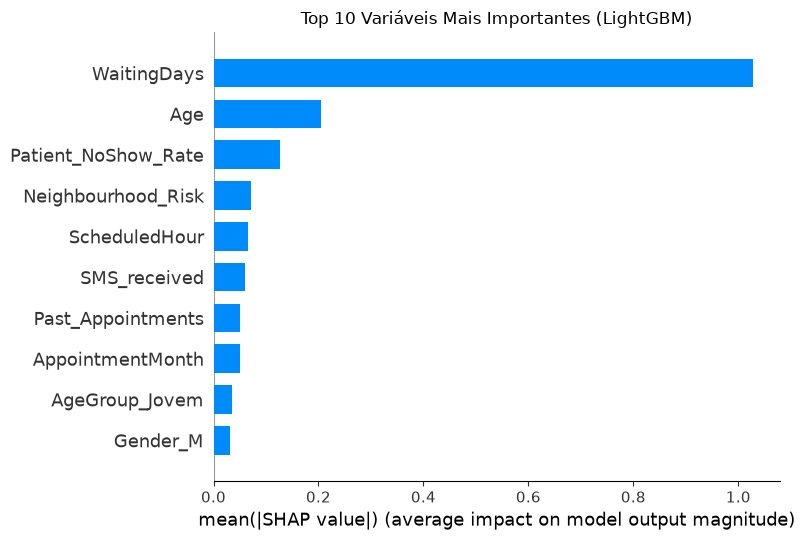

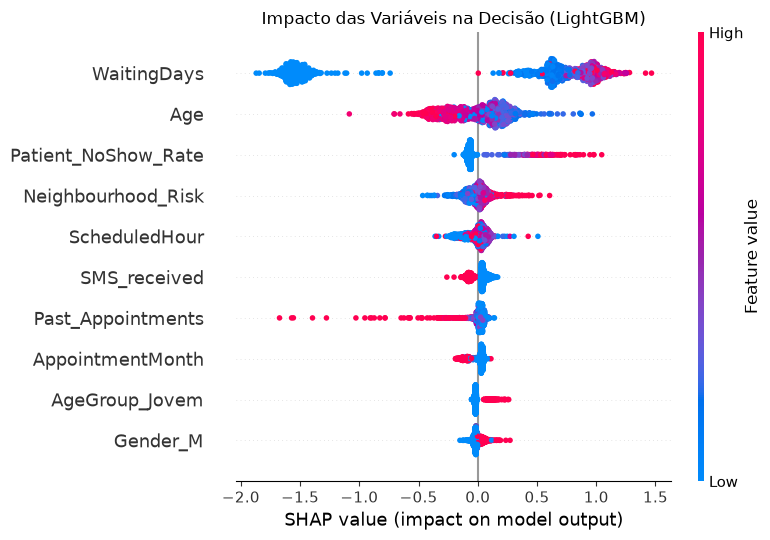

In [24]:
# 1. Forçar a escolha do LightGBM (Opção 2 - Rápido e de Alta Performance)
best_model_name = 'LightGBM'
print(f"O modelo escolhido para explicação foi: {best_model_name}")

vencedor = final_trained_models[best_model_name]

print("\nA calcular valores SHAP... (A amostra de 1500 linhas processa em segundos)")

# Retirar uma amostra representativa para o SHAP
X_test_sample = shap.sample(X_test_opt, 1500, random_state=42)

# 2. Configurar e calcular o SHAP
explainer = shap.TreeExplainer(vencedor)
shap_values = explainer.shap_values(X_test_sample) 

# Lidar com o formato de saída do SHAP
if isinstance(shap_values, list):
    shap_values_alvo = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_values_alvo = shap_values[:, :, 1]
else:
    shap_values_alvo = shap_values

# Plot 1: Gráfico de Barras (Importância Absoluta)
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_alvo, X_test_sample, plot_type="bar", max_display=10, show=False)
plt.title(f"Top 10 Variáveis Mais Importantes ({best_model_name})")
plt.tight_layout()
plt.show() 

# Plot 2: Gráfico de Dispersão (Direção do Impacto)
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values_alvo, X_test_sample, max_display=10, show=False)
plt.title(f"Impacto das Variáveis na Decisão ({best_model_name})")
plt.tight_layout()
plt.show()

### 7. Simulação de Eficiencia Operacional
Execução do modelo vencedor no conjunto de teste para simular o impacto prático na redução do tempo administrativo e na recuperação de horas médicas no hospital.

In [25]:
print("A calcular impacto operacional do melhor modelo...")
vencedor = final_trained_models[best_model_name]
y_pred_business = vencedor.predict(X_test_opt)

data_analyze.simulate_operational_efficiency(y_test_opt, y_pred_business)

A calcular impacto operacional do melhor modelo...
IMPACTO OPERACIONAL: OTIMIZAÇÃO DE RECURSOS HOSPITALARES

Total de Pacientes Avaliados: 22105
Ausências Reais: 4495

> TEMPO ADMINISTRATIVO (Triagem e Confirmação de Consultas):
   - Sem IA (Ligar a todos):     1105 horas de trabalho
   - Com IA (Apenas Alto Risco): 572 horas de trabalho
   - Poupou-se à equipa:      533 horas!

> TEMPO MÉDICO (Horas de consultório vazias):
   - Sem IA (Todas as faltas):   2248 horas desperdiçadas
   - Com IA (Faltas reduzidas):  1498 horas desperdiçadas
   - Tempo médico recuperado: 749 horas! (Aprox. 1498 consultas salvas)

